# Explainable Demand Forecasting & Inventory Optimization - results walkthrough

This notebook only **reads** the artefacts produced by `python run_project.py` (tables in `outputs/tables`, figures in `outputs/figures`) and re-computes a few numbers with the project's own functions, so every statement can be traced to code. Costs are **hypothetical**; observed sales may underestimate true demand during stockouts.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().resolve().parent
sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np
from IPython.display import Image, display, Markdown
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
T, F = ROOT / 'outputs' / 'tables', ROOT / 'outputs' / 'figures'
def show(name, width=900): display(Image(filename=str(F / name), width=width))

## 1. Data and sample
M5 Walmart data (30,490 series x 1,941 days). 18 item-store series were drawn with TRAIN information only (one store per state, three demand tiers, seeded draws).

In [2]:
sel = pd.read_csv(ROOT / 'data' / 'processed' / 'selected_series.csv')
sel[['series_id','tier','cat_id','train_mean','train_zero_share','train_adi','train_cv2','train_sb_class']].round(2)

,series_id,tier,cat_id,train_mean,train_zero_share,train_adi,train_cv2,train_sb_class
0,FOODS_3_449_CA_3,high,FOODS,8.30,0.08,1.09,0.33,smooth
1,HOUSEHOLD_1_114_CA_3,high,HOUSEHOLD,9.00,0.08,1.09,0.28,smooth
2,FOODS_3_784_CA_3,medium,FOODS,1.35,0.50,2.01,0.46,intermittent
3,HOUSEHOLD_2_270_CA_3,medium,HOUSEHOLD,0.87,0.55,2.23,0.39,intermittent
4,HOBBIES_1_377_CA_3,low,HOBBIES,0.30,0.74,3.87,0.13,intermittent
5,HOUSEHOLD_2_228_CA_3,low,HOUSEHOLD,0.51,0.65,2.82,0.31,intermittent
6,FOODS_2_347_TX_2,high,FOODS,4.00,0.12,1.14,0.34,smooth
7,HOUSEHOLD_1_247_TX_2,high,HOUSEHOLD,3.45,0.10,1.11,0.35,smooth
8,FOODS_3_729_TX_2,medium,FOODS,1.38,0.48,1.91,0.61,lumpy
9,HOBBIES_1_034_TX_2,medium,HOBBIES,0.87,0.49,1.96,0.37,intermittent


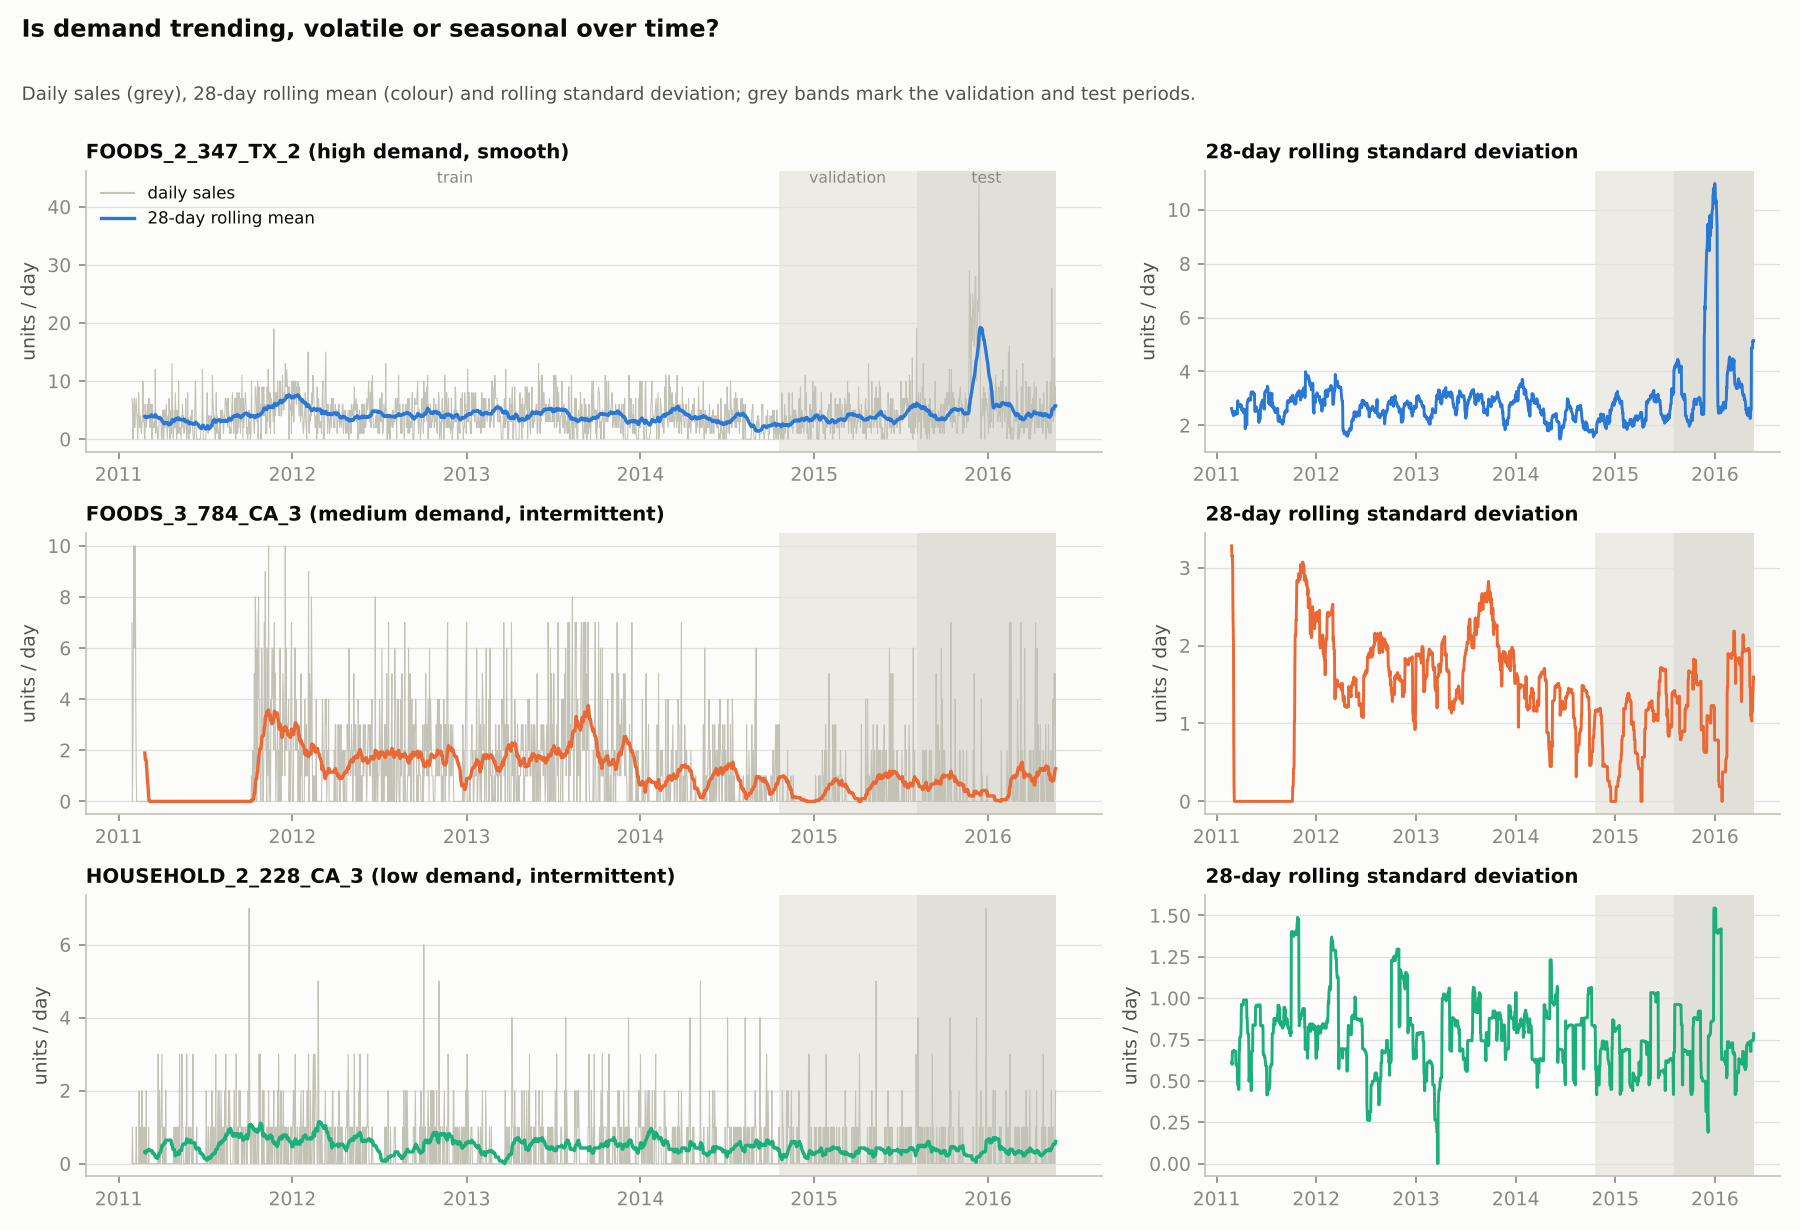

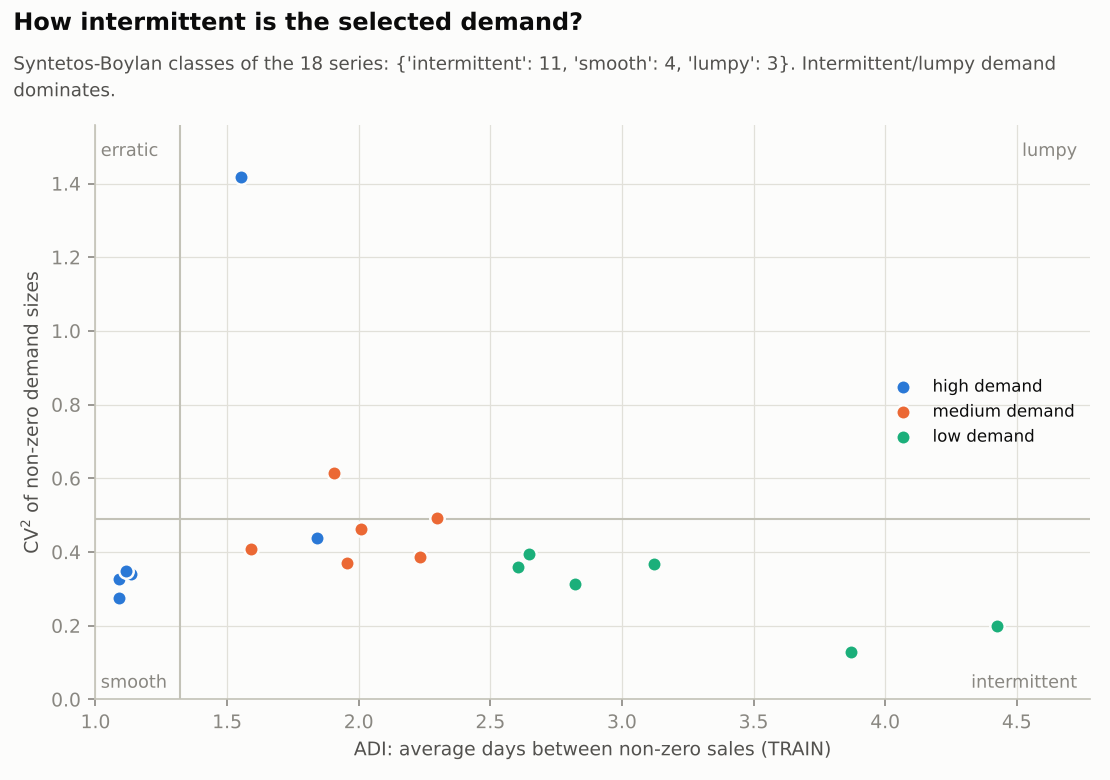

In [3]:
show('eda_01_daily_rolling.png'); show('eda_06_intermittency_map.png', 650)

## 2. Forecast accuracy (test period, pooled over 18 series)

In [4]:
t = pd.read_csv(T / 'forecast_summary_test.csv')
tab = t[t.H.isin([7,14,28])].pivot(index='model', columns='H', values='WAPE').round(2).sort_values(28)
tab.columns = [f'{c}-day WAPE %' for c in tab.columns]
tab

,7-day WAPE %,14-day WAPE %,28-day WAPE %
model,,,
XGBoost,38.46,32.79,29.85
SARIMA,38.01,33.71,31.56
MovingAverage,39.42,34.48,32.15
Holt,37.57,34.22,32.73
HoltWinters,37.70,34.35,32.85
SES,37.60,34.31,32.86
Croston,40.66,36.04,33.63
SeasonalNaive,40.91,39.90,40.33
Naive,70.42,70.88,72.82


In [5]:
best = pd.read_csv(T / 'best_model_by_horizon.csv')
best[['H','best_by_validation_WAPE','best_by_test_WAPE','test_WAPE','runner_up_test_WAPE','validation_choice_equals_test_best']]

,H,best_by_validation_WAPE,best_by_test_WAPE,test_WAPE,runner_up_test_WAPE,validation_choice_equals_test_best
0,3,XGBoost,XGBoost,47.609644,HoltWinters,True
1,7,SARIMA,Holt,37.568585,SES,False
2,14,SARIMA,XGBoost,32.789945,SARIMA,False
3,28,SARIMA,XGBoost,29.846853,SARIMA,False


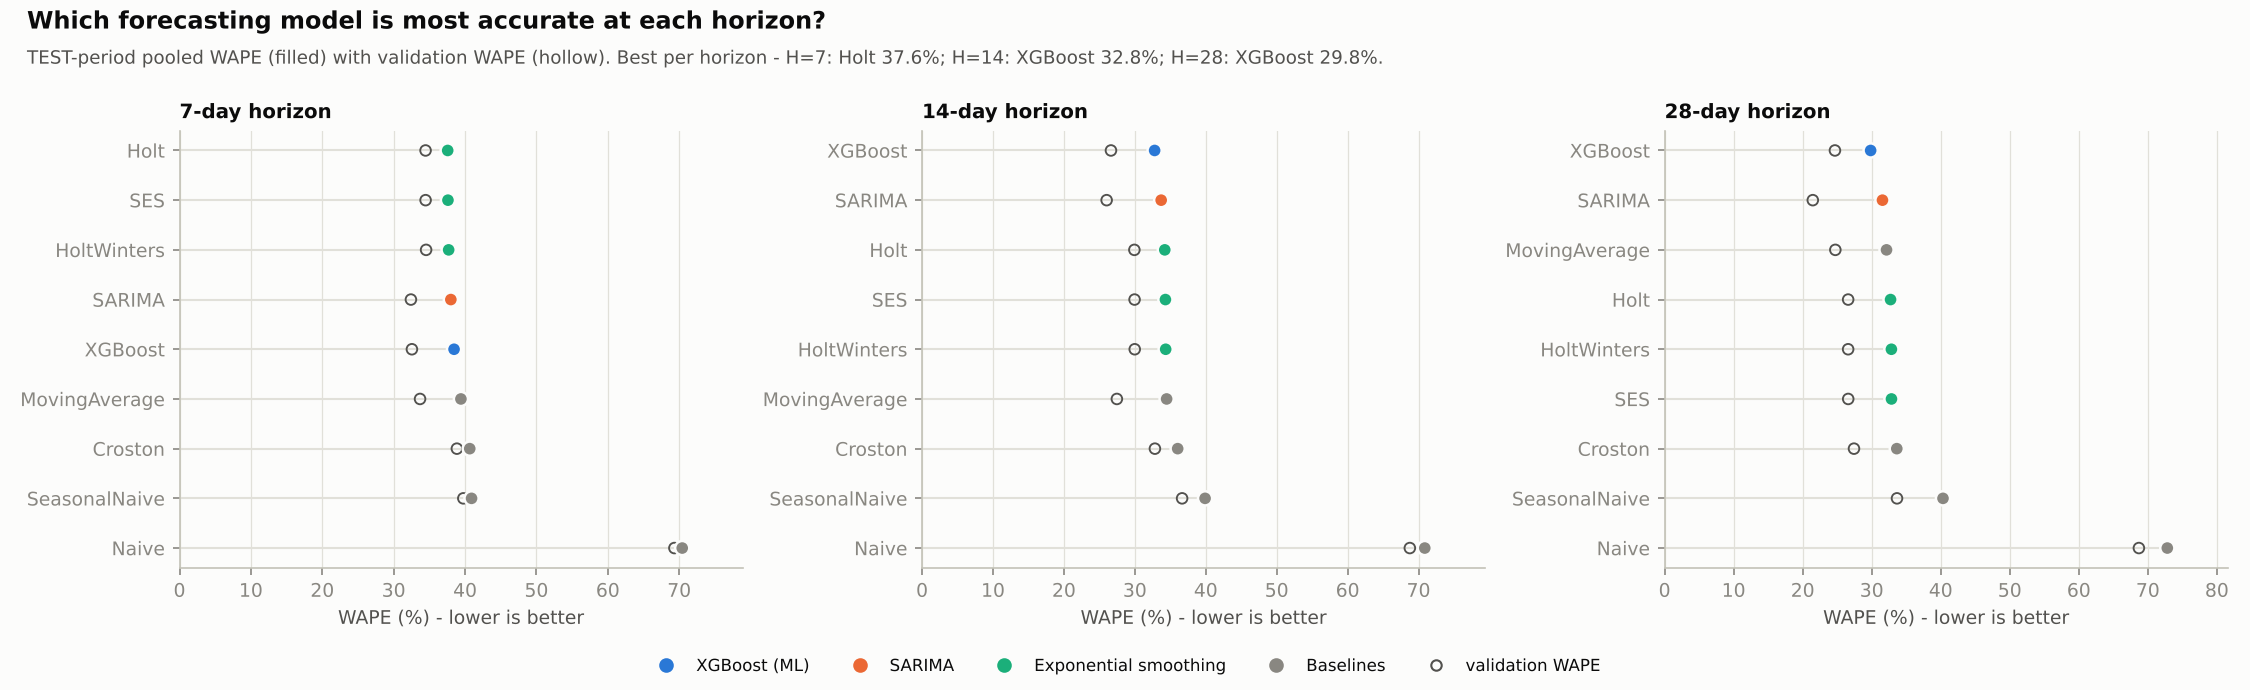

In [6]:
show('fc_02_model_comparison_wape.png')

### Is the difference real? Diebold-Mariano (XGBoost vs each model, Holm-adjusted)

In [7]:
dm = pd.read_csv(T / 'dm_tests_panel.csv')
x = dm[(dm.ref=='XGBoost') & (dm.loss=='abs')].pivot(index='model_b', columns='H', values='p_holm').round(3)
x.columns = [f'p_Holm H={c}' for c in x.columns]; x

,p_Holm H=7,p_Holm H=14,p_Holm H=28
model_b,,,
Croston,0.489,1.0,1.000
Holt,0.000,1.0,0.423
HoltWinters,0.001,1.0,0.454
MovingAverage,0.313,1.0,1.000
Naive,0.000,0.0,0.000
SARIMA,0.068,1.0,0.689
SES,0.001,1.0,0.511
SeasonalNaive,0.001,0.0,0.000


## 3. Explainability (SHAP)

In [8]:
imp = pd.read_csv(T / 'shap_importance.csv')
imp[imp.H==7].head(8)[['feature','group','mean_abs_shap','share_of_total','corr(feature value, shap)']].round(3)

,feature,group,mean_abs_shap,share_of_total,"corr(feature value, shap)"
0,rolling_mean_28,history,8.322,0.535,0.970
1,rolling_mean_7,history,1.818,0.117,0.936
2,rolling_mean_14,history,1.324,0.085,0.280
3,rolling_std_28,history,0.719,0.046,0.068
4,snap_days_window,known_ahead,0.705,0.045,0.844
5,lag_1,history,0.615,0.040,0.793
6,price,history,0.577,0.037,-0.809
7,year,calendar_origin,0.318,0.020,-0.008


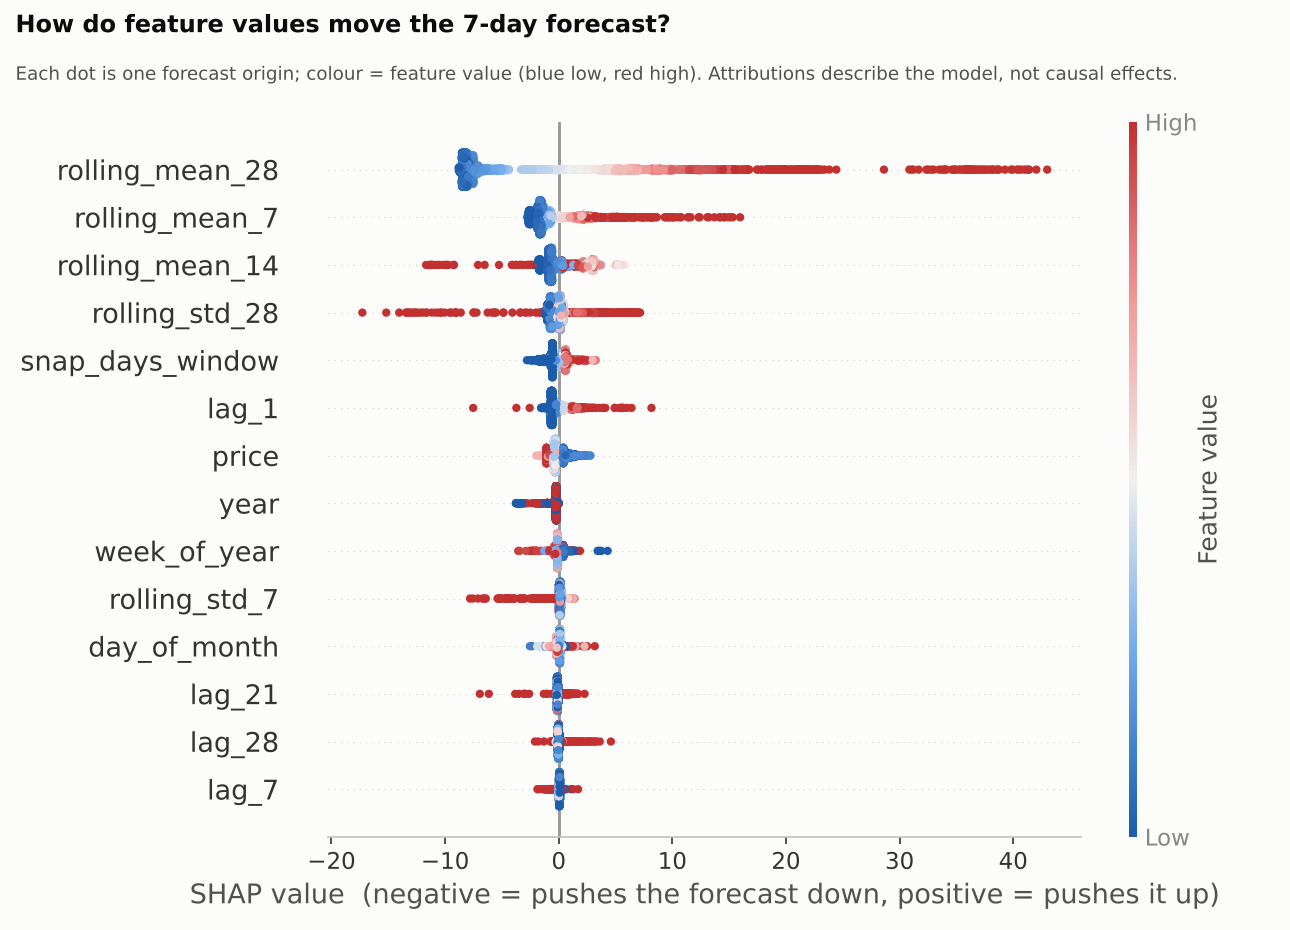

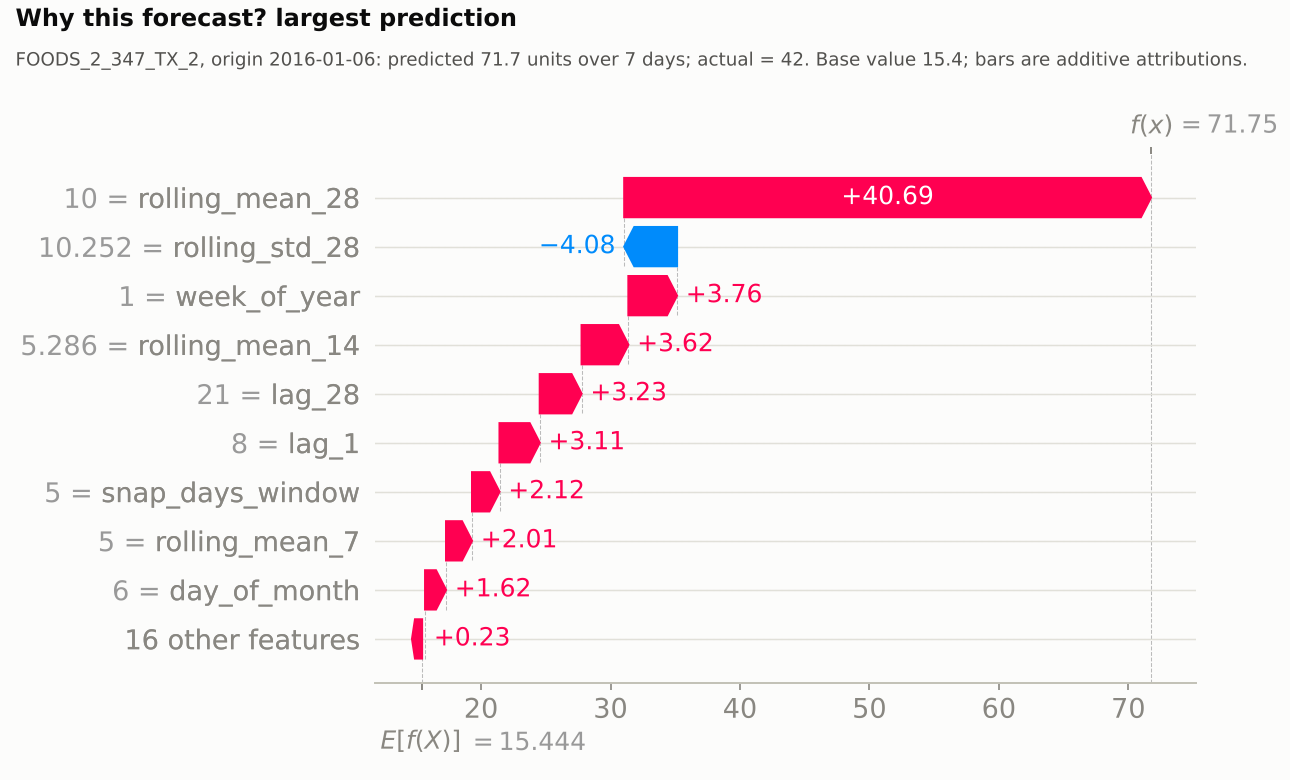

In [9]:
show('shap_summary_H7.png', 750); show('shap_individual_H7_1.png', 750)

## 4. Uncertainty

In [10]:
cov = pd.read_csv(T / 'uncertainty_coverage_test.csv')
cov[(cov.chosen_method) & cov.model.isin(['XGBoost','SARIMA','MovingAverage']) & cov.H.isin([7,28])].pivot_table(index=['model','H'], columns='level', values='coverage').round(3)

level               0.8    0.9
model         H               
MovingAverage 7   0.812  0.882
              28  0.802  0.870
SARIMA        7   0.800  0.884
              28  0.696  0.799
XGBoost       7   0.788  0.872
              28  0.793  0.881

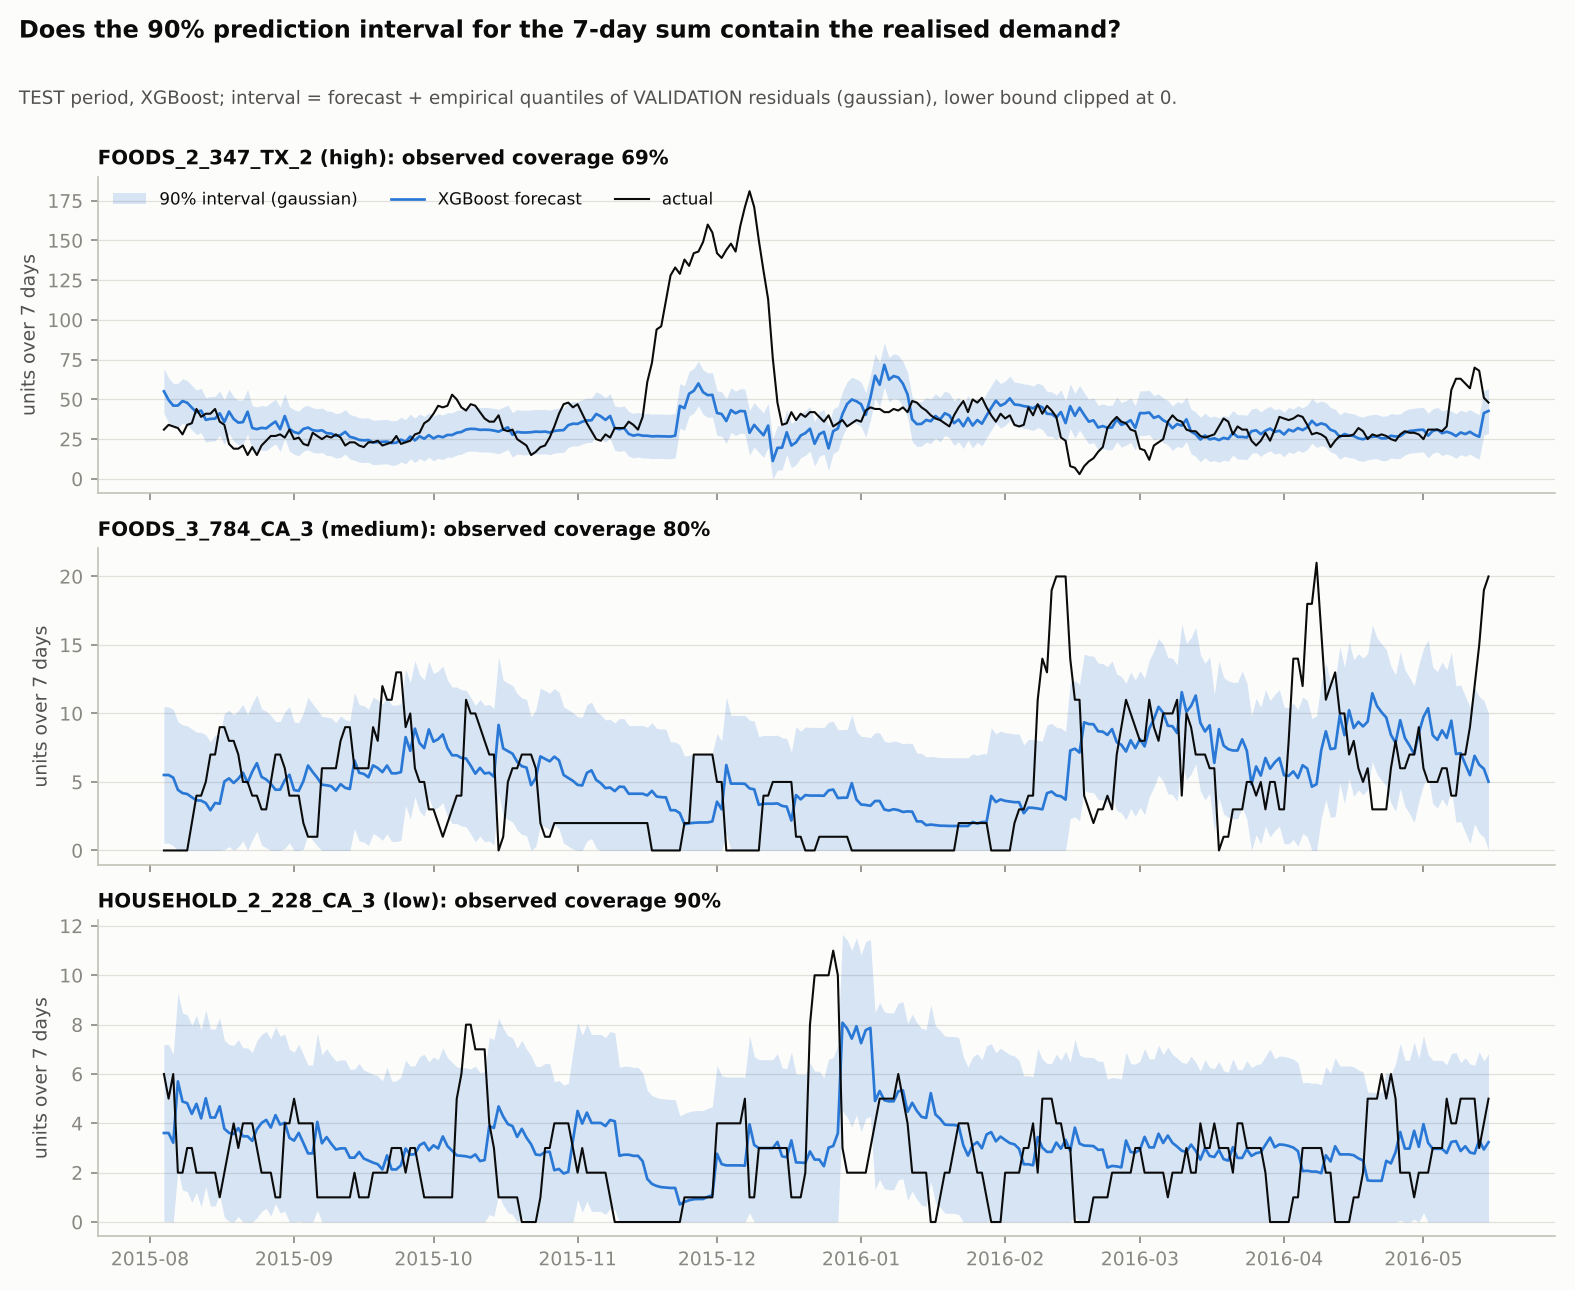

In [11]:
show('unc_01_prediction_interval_H7.png')

## 5. Inventory results (MEDIUM penalty, 95% target)

In [12]:
inv = pd.read_csv(T / 'final_inventory_results.csv')
inv[(inv.Cost_Scenario=='MEDIUM') & (inv.Service_Level==0.95)][['Policy','Forecast_Model','Lead_Time_days','Stockouts','Fill_Rate','Cycle_Service_Level','Average_Inventory','Holding_Cost','Ordering_Cost','Stockout_Cost','Total_Cost']].round(3)

,Policy,Forecast_Model,Lead_Time_days,Stockouts,Fill_Rate,Cycle_Service_Level,Average_Inventory,Holding_Cost,Ordering_Cost,Stockout_Cost,Total_Cost
38,A_historical,none (28-day trailing mean/std),3,43,0.981,0.794,594.387,195.243,145.0,170.718,510.961
39,B_forecast_driven,XGBoost,3,29,0.975,0.879,607.904,212.396,141.0,145.035,498.431
44,A_historical,none (28-day trailing mean/std),7,65,0.960,0.746,675.990,223.417,141.0,283.443,647.860
45,B_forecast_driven,SARIMA,7,45,0.963,0.848,661.123,237.717,140.0,215.067,592.784
50,A_historical,none (28-day trailing mean/std),14,96,0.936,0.752,750.175,252.691,141.0,447.021,840.712
51,B_forecast_driven,SARIMA,14,55,0.945,0.887,787.284,287.777,143.0,293.415,724.192


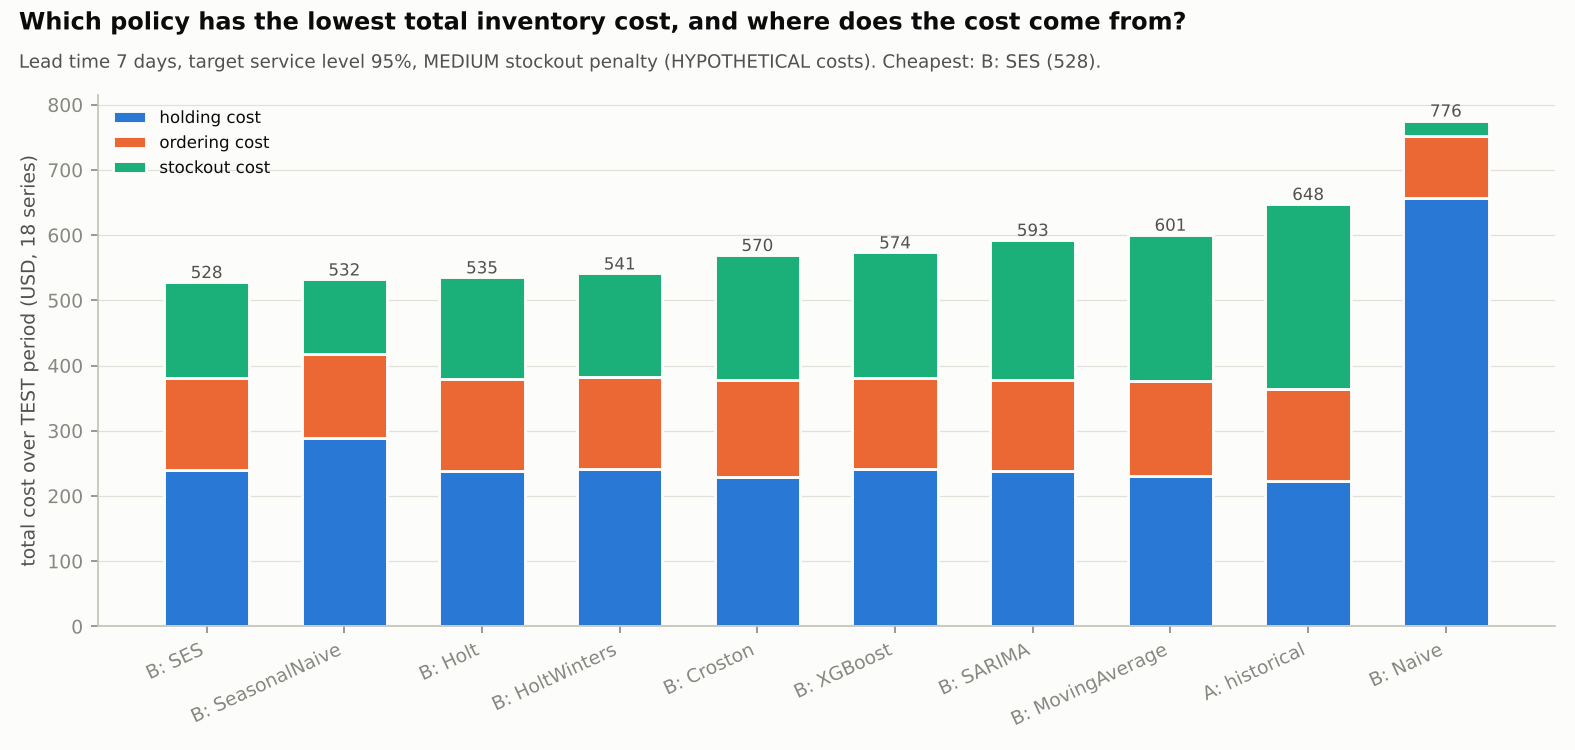

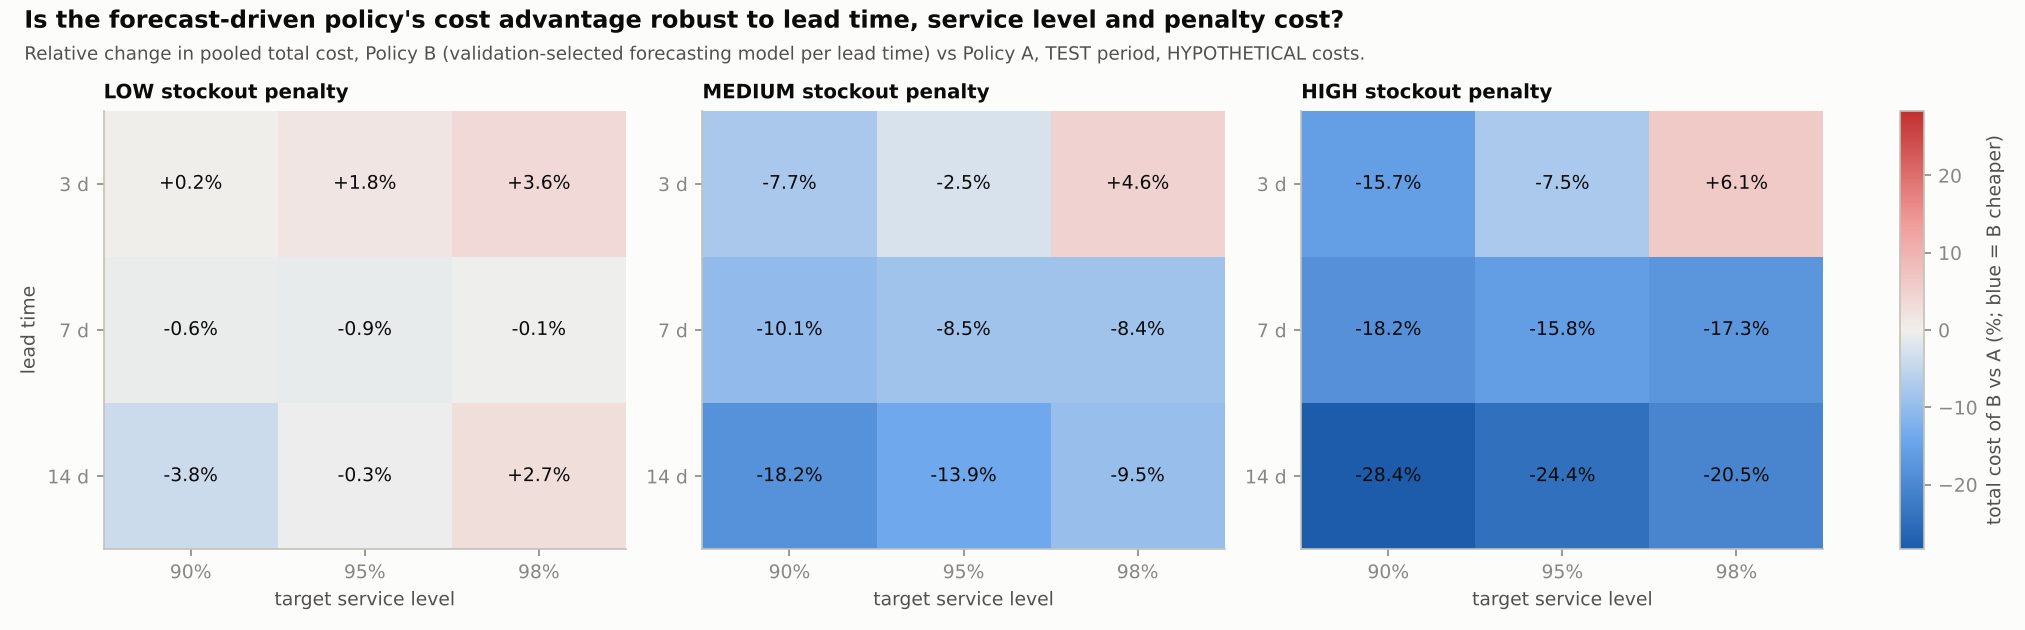

In [13]:
show('inv_05_total_cost_components.png'); show('inv_06_sensitivity_heatmaps.png')

### Paired bootstrap, forecast-driven policy B vs historical baseline A (negative = B cheaper)

In [14]:
p = pd.read_csv(T / 'inventory_paired_bootstrap_B_vs_A.csv')
p[p.scenario=='MEDIUM'][['L','SL','policy_B','rel_diff_pooled','boot_ci_low','boot_ci_high','series_B_cheaper']].round(3)

,L,SL,policy_B,rel_diff_pooled,boot_ci_low,boot_ci_high,series_B_cheaper
9,3,0.90,XGBoost,-0.077,-0.260,0.146,10
10,3,0.95,XGBoost,-0.025,-0.237,0.245,10
11,3,0.98,XGBoost,0.046,-0.151,0.277,12
12,7,0.90,SARIMA,-0.101,-0.261,0.070,11
13,7,0.95,SARIMA,-0.085,-0.208,0.052,10
14,7,0.98,SARIMA,-0.084,-0.196,0.042,8
15,14,0.90,SARIMA,-0.182,-0.362,0.037,13
16,14,0.95,SARIMA,-0.139,-0.321,0.069,13
17,14,0.98,SARIMA,-0.095,-0.208,0.021,11


## 6. Does the most accurate forecast give the lowest cost?

In [15]:
s = pd.read_csv(T / 'accuracy_vs_cost_summary.csv')
s[s.SL==0.95][['scenario','L','best_by_test_WAPE','best_by_total_cost','spearman_testWAPE_vs_cost_excl_Naive']].round(2)

,scenario,L,best_by_test_WAPE,best_by_total_cost,spearman_testWAPE_vs_cost_excl_Naive
1,LOW,3,XGBoost,SES,0.12
4,LOW,7,Holt,SES,0.81
7,LOW,14,XGBoost,XGBoost,0.38
10,MEDIUM,3,XGBoost,SeasonalNaive,-0.62
13,MEDIUM,7,Holt,SES,0.29
16,MEDIUM,14,XGBoost,SES,0.02
19,HIGH,3,XGBoost,Naive,-0.67
22,HIGH,7,Holt,SeasonalNaive,0.14
25,HIGH,14,XGBoost,SeasonalNaive,-0.48


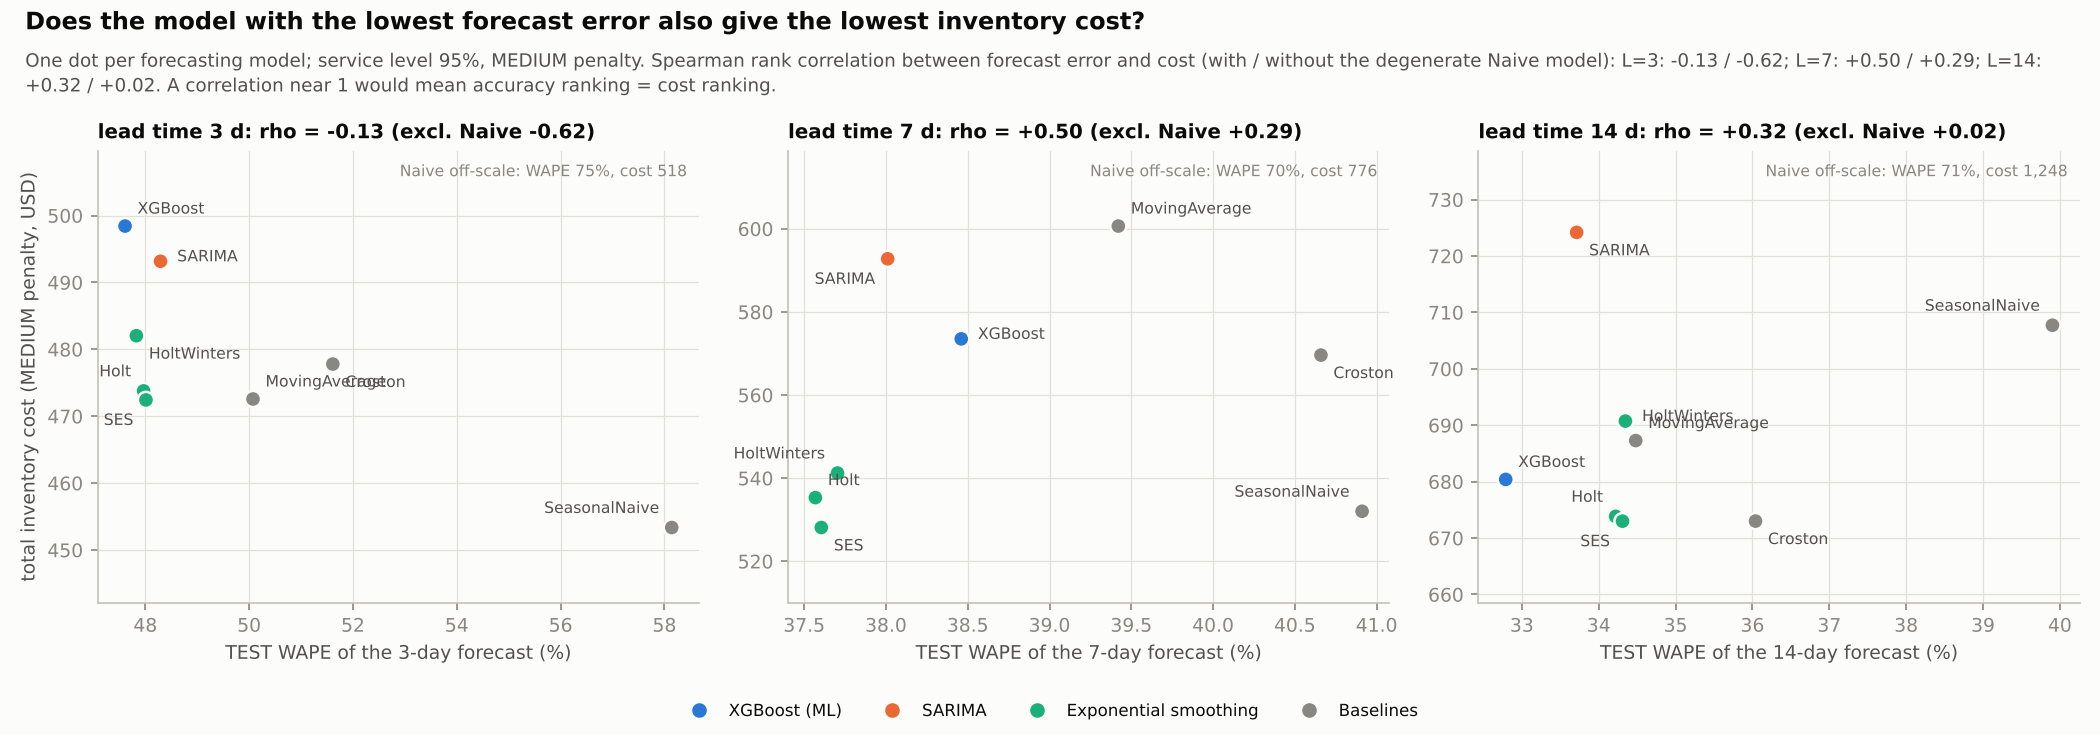

In [16]:
show('inv_07_accuracy_vs_cost.png')

## 7. Try it yourself: simulate one series with the project's functions
The cell below re-runs the daily simulator for one series under the historical policy A and the forecast-driven policy B (the validation-selected model) and prints the realised metrics - the same code that produced the tables.

In [17]:
from src.forecast_core import load_context, ForecastBook
from src import inventory_experiments as ie, inventory as invm, evaluation as ev
ctx = load_context(); book = ForecastBook(ctx).load(); ev.select_ma_alias(book)
sig = pd.read_csv(T / 'sigma_table.csv')
inputs = ie.prepare_inputs(ctx)
s_idx, L, SL = 6, 7, 0.95
polB = pd.read_csv(T / 'headline_policy_B_models.csv').set_index('lead_time').loc[L, 'model']
rows = []
for pol in [ie.POLICY_A, polB]:
    rop, S = ie.policy_arrays(ctx, book, inputs, pol, L, SL, sig)
    led = invm.simulate(inputs['demand'][s_idx], rop[s_idx], S[s_idx], L, ie.initial_inventory(inputs, L)[s_idx])
    m = invm.add_costs(invm.ledger_metrics(led, L), inputs['cost_params'][s_idx])
    rows.append({'series': ctx.ids[s_idx], 'policy': pol, 'fill_rate': m['fill_rate'], 'stockout_days': m['stockout_days'], 'avg_inventory': m['avg_inventory'], 'total_cost_MEDIUM': m['total_cost_MEDIUM']})
pd.DataFrame(rows).round(3)

,series,policy,fill_rate,stockout_days,avg_inventory,total_cost_MEDIUM
0,FOODS_2_347_TX_2,A_historical,0.899,14,92.462,131.162
1,FOODS_2_347_TX_2,SARIMA,0.869,18,67.740,154.303


*A single series can favour either policy* - the pooled result is an average over 18 series. The column `series_B_cheaper` in `inventory_paired_bootstrap_B_vs_A.csv` (section 5) counts, per configuration, in how many of the 18 series policy B had the lower total cost; the bootstrap interval there quantifies how much the pooled difference could vary across series.

## 8. Take-aways (computed from the tables above)

In [18]:
g = lambda L: inv[(inv.Cost_Scenario=='MEDIUM')&(inv.Service_Level==0.95)&(inv.Lead_Time_days==L)].set_index('Policy')
for L in (3,7,14):
    a, b = g(L).loc['A_historical','Total_Cost'], g(L).loc['B_forecast_driven','Total_Cost']
    print(f'L={L:2d}: total cost B vs A = {100*(b/a-1):+.1f}%  (cycle service level A {100*g(L).loc["A_historical","Cycle_Service_Level"]:.0f}% -> B {100*g(L).loc["B_forecast_driven","Cycle_Service_Level"]:.0f}%)')
print('Cells where the best forecast is also the cheapest policy:', int(s.same_best_test_accuracy_and_cost.sum()), 'of', len(s))

L= 3: total cost B vs A = -2.5%  (cycle service level A 79% -> B 88%)
L= 7: total cost B vs A = -8.5%  (cycle service level A 75% -> B 85%)
L=14: total cost B vs A = -13.9%  (cycle service level A 75% -> B 89%)
Cells where the best forecast is also the cheapest policy: 2 of 27
